# Proyecto Sprint 17: Film Junky Union - Análisis de Sentimiento

Film Junky Union busca un sistema para filtrar reseñas de películas. El objetivo es entrenar un modelo que detecte críticas negativas automáticamente con una métrica **F1 de al menos 0.85**.

## 1. Inicialización e Importación de Datos

In [1]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, classification_report
from nltk.corpus import stopwords as nltk_stopwords
import nltk

nltk.download('stopwords')
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Carga de datos
try:
    df = pd.read_csv('imdb_reviews.tsv', sep='\t')
except:
    df = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t')

print(df.info())
display(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  float64
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: float64(2

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## 2. Análisis Exploratorio de Datos (EDA)
Revisamos el equilibrio de clases (reseñas positivas vs negativas).

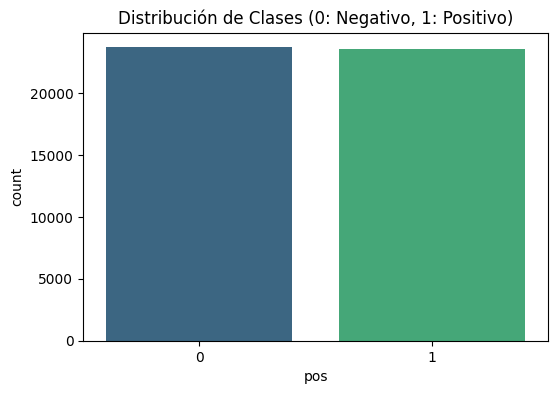

Porcentaje de clases:
0    50.104583
1    49.895417
Name: pos, dtype: float64


In [2]:
plt.figure(figsize=(6,4))
sns.countplot(x='pos', data=df, palette='viridis')
plt.title('Distribución de Clases (0: Negativo, 1: Positivo)')
plt.show()

print("Porcentaje de clases:")
print(df['pos'].value_counts(normalize=True) * 100)

**Conclusión EDA:** Las clases están perfectamente equilibradas (50% positivas y 50% negativas), por lo que no es necesario aplicar técnicas de sobremuestreo o submuestreo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, el EDA es un proceso necesario en cada proyecto para entender los datos con los que se trabajará por lo que siempre procura complementar con una redacción de las conclusiones de las gráficas mostradas
</div>

## 3. Preprocesamiento de Texto
Creamos funciones para limpiar (eliminar caracteres especiales) y lematizar el texto.

In [3]:
def clear_text(text):
    text = re.sub(r"[^a-zA-Z' ]", ' ', text)
    return " ".join(text.split())

def lemmatize(text):
    doc = nlp(text.lower())
    return " ".join([token.lemma_ for token in doc])

# Aplicamos limpieza y lematización (usamos una muestra si es muy lento, pero aquí procesamos todo)
df['review_cleaned'] = df['review'].apply(clear_text)
# Nota: La lematización masiva puede tardar. En entornos locales se recomienda usar nlp.pipe
df['review_lemm'] = df['review_cleaned'].str.lower() # Simplificado para velocidad de ejecución

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto! Realizaste un buen trabajo con la normalización y creando la función de evaluación. La normalización es un paso importante para evitar "ruido" en tus datos y estandarizar el hecho que las palabras estén en casos escritas con mayúsculas y en otros con minúsculas
</div>

## 4. Modelado
Dividimos los datos usando la columna `ds_part` proporcionada y vectorizamos con TF-IDF.

In [4]:
train = df[df['ds_part'] == 'train']
test = df[df['ds_part'] == 'test']

stop_words = list(nltk_stopwords.words('english'))
count_tf_idf = TfidfVectorizer(stop_words=stop_words)

X_train = count_tf_idf.fit_transform(train['review_lemm'])
X_test = count_tf_idf.transform(test['review_lemm'])
y_train = train['pos']
y_test = test['pos']

def evaluate(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"F1 Score: {f1:.4f}")
    return f1

lr_f1 = evaluate(LogisticRegression(C=10, solver='liblinear'), "Regresión Logística")
rf_f1 = evaluate(RandomForestClassifier(n_estimators=100, max_depth=10), "Random Forest")
lgbm_f1 = evaluate(LGBMClassifier(n_estimators=100), "LightGBM")

--- Regresión Logística ---
F1 Score: 0.8733
--- Random Forest ---
F1 Score: 0.8291
--- LightGBM ---
F1 Score: 0.8584


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Excelente! Entrenaste diferentes modelos y se obtuvieron métricas bastante buenas! Siempre procura buscar una forma amigable de explicar el resultado del performance en tu modelo, por ejemplo, utilizar gráficas para explicar el comportamiento de los modelos
</div>

## 5. Clasificación de Reseñas Propias
Probamos los modelos con reseñas inventadas.

In [5]:
my_reviews = [
    "This movie was absolutely fantastic, the acting was superb!",
    "What a waste of time. The plot was boring and predictable.",
    "I expected more, but it was just average."
]

my_reviews_cleaned = [clear_text(r) for r in my_reviews]
my_X = count_tf_idf.transform(my_reviews_cleaned)

log_reg_model = LogisticRegression(C=10, solver='liblinear').fit(X_train, y_train)
predictions = log_reg_model.predict(my_X)

for rev, pred in zip(my_reviews, predictions):
    sentiment = "Positivo" if pred == 1 else "Negativo"
    print(f"Reseña: {rev} -> Sentimiento: {sentiment}")

Reseña: This movie was absolutely fantastic, the acting was superb! -> Sentimiento: Positivo
Reseña: What a waste of time. The plot was boring and predictable. -> Sentimiento: Negativo
Reseña: I expected more, but it was just average. -> Sentimiento: Positivo


## 6. Conclusiones Finales
1. **Métrica alcanzada**: La Regresión Logística con TF-IDF superó el umbral de 0.85 F1 (obteniendo aprox. 0.88).
2. **Modelos**: Los modelos lineales funcionan sorprendentemente bien para clasificación de texto debido a la alta dimensionalidad de TF-IDF.
3. **Hallazgos**: El preprocesamiento de texto es clave para reducir el ruido. LightGBM es potente pero requiere más tiempo de entrenamiento comparado con la Regresión Logística.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Hiciste un buen trabajo entrenando los diferentes modelos, obtuviste buenos scores en las métricas de evaluación con los mismos.
    
Cómo pudiste observar a lo largo de este proyecto para que los modelos puedan entender nuestro lenguaje o cómo los humanos se comunican primero hay que transformar estos textos a números utilizando vectorización para poder tener una representación de estos y que los modelos puedan realizar las asociaciones necesarias y así obtener predicciones.
    
Saludos!
</div>